In [1]:
from pathlib import Path

import uproot

DATA_FILENAME = "JetNtuple_RunIISummer16_13TeV_MC_1.root"
SEARCH_ROOTS = (Path.cwd(), Path.cwd().parent)
candidate_paths = [
    base / relative_path
    for base in SEARCH_ROOTS
    for relative_path in (
        Path("data") / "raw" / DATA_FILENAME,
        Path("QCDJetsMachineLearning") / DATA_FILENAME,
    )
]
ROOT_PATH = next((path for path in candidate_paths if path.is_file()), None)
if ROOT_PATH is None:
    raise FileNotFoundError(f"Could not find {DATA_FILENAME} from {Path.cwd()}")
ROOT_PATH = ROOT_PATH.resolve()
print(f"Data file: {ROOT_PATH}")

f = uproot.open(ROOT_PATH)
classnames = f.classnames(recursive=True)   # {name: ROOT classname} — digs into every subdirectory, not just the top level

# takes objects of a certain type (Tree or RNTuple)
tree_candidates = [k for k, cls in classnames.items() if "Tree" in cls or "RNTuple" in cls]

# function to extract the cycle number (version)
def cycle_num(key):
    return int(key.rsplit(";", 1)[1]) if ";" in key else 0

# the goal is to take the highest cycle (newest version)
tree_candidates.sort(key=cycle_num, reverse=True)   
tree = f[tree_candidates[0]]

print(f"Using: {tree_candidates[0]}")
#print(tree.keys())   # branch/features names

for key in tree.keys():
    print(key)

Data file: D:\OneDrive - The University of Manchester\summer2026\SCIML\jet praticales\data\raw\JetNtuple_RunIISummer16_13TeV_MC_1.root
Using: AK4jets/jetTree;3
jetPt
jetEta
jetPhi
jetMass
jetGirth
jetArea
jetRawPt
jetRawMass
jetLooseID
jetTightID
jetGenMatch
jetQGl
QG_ptD
QG_axis2
QG_mult
partonFlav
hadronFlav
physFlav
isPhysUDS
isPhysG
isPhysOther
isPartonUDS
isPartonG
isPartonOther
jetChargedHadronMult
jetNeutralHadronMult
jetChargedMult
jetNeutralMult
jetMult
nPF
PF_pT
PF_dR
PF_dTheta
PF_dPhi
PF_dEta
PF_mass
PF_id
PF_fromPV
PF_fromAK4Jet
genJetPt
genJetEta
genJetPhi
genJetMass
nGenJetPF
genJetPF_pT
genJetPF_dR
genJetPF_dTheta
genJetPF_mass
genJetPF_id
eventJetMult
jetPtOrder
dPhiJetsLO
dEtaJetsLO
alpha
event
run
lumi
pthat
eventWeight
rhoAll
rhoCentral
rhoCentralNeutral
rhoCentralChargedPileUp
PV_npvsGood
Pileup_nPU
Pileup_nTrueInt


In [2]:
import awkward as ak
import numpy as np
import torch
from torch_geometric.data import Data

K_NEIGHBORS = 8
particle_feature_names = ("pT", "dEta", "dPhi")

# Read labels, event IDs, particle features, and the AK4 constituent mask.
branches = [
    "run",
    "lumi",
    "event",
    "physFlav",
    "isPhysUDS",
    "isPhysG",
    "PF_pT",
    "PF_dEta",
    "PF_dPhi",
    "PF_fromAK4Jet",
]
raw_data = tree.arrays(branches, library="ak")

# Keep only jets with one unambiguous binary label.
is_quark = raw_data["isPhysUDS"] == 1
is_gluon = raw_data["isPhysG"] == 1
selected_jets = raw_data[is_quark ^ is_gluon]


def build_knn_edges(pos, k=K_NEIGHBORS):
    """Return directed k-nearest-neighbour edges using native PyTorch."""
    num_nodes = pos.size(0)
    if num_nodes < 2:
        return torch.empty((2, 0), dtype=torch.long)

    k = min(k, num_nodes - 1)
    distances = torch.cdist(pos, pos)
    distances.fill_diagonal_(float("inf"))
    neighbours = distances.topk(k, largest=False).indices

    target = torch.arange(num_nodes).repeat_interleave(k)
    source = neighbours.reshape(-1)
    return torch.stack((source, target), dim=0)


# Create one PyTorch Geometric Data object per jet.
jet_graphs = []
for jet in selected_jets:
    constituent_mask = ak.to_numpy(jet["PF_fromAK4Jet"]) == 1
    particle_matrix = np.column_stack(
        [
            ak.to_numpy(jet["PF_pT"])[constituent_mask],
            ak.to_numpy(jet["PF_dEta"])[constituent_mask],
            ak.to_numpy(jet["PF_dPhi"])[constituent_mask],
        ]
    )

    x = torch.as_tensor(particle_matrix, dtype=torch.float32)
    pos = torch.as_tensor(
        np.column_stack(
            [
                ak.to_numpy(jet["PF_dEta"])[constituent_mask],
                ak.to_numpy(jet["PF_dPhi"])[constituent_mask],
            ]
        ),
        dtype=torch.float32,
    )

    jet_graphs.append(
        Data(
            x=x,
            pos=pos,
            edge_index=build_knn_edges(pos),
            y=torch.tensor([int(jet["isPhysG"])], dtype=torch.long),
            original_flavor=torch.tensor([int(jet["physFlav"])], dtype=torch.long),
            run=torch.tensor([int(jet["run"])], dtype=torch.long),
            lumi=torch.tensor([int(jet["lumi"])], dtype=torch.long),
            event=torch.tensor([int(jet["event"])], dtype=torch.long),
            event_id=torch.tensor([int(jet["event"])], dtype=torch.long),
        )
    )

print(f"PyG graphs created: {len(jet_graphs):,} / {len(raw_data):,} jets")
print("Node feature columns:", particle_feature_names)
print("Target convention: 0 = light quark (UDS), 1 = gluon")
print(jet_graphs[0])

d:\OneDrive - The University of Manchester\summer2026\SCIML\jet praticales\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyG graphs created: 13,912 / 28,614 jets
Node feature columns: ('pT', 'dEta', 'dPhi')
Target convention: 0 = light quark (UDS), 1 = gluon
Data(x=[26, 3], edge_index=[2, 208], y=[1], pos=[26, 2], original_flavor=[1], event_id=[1])


# Variables created in the previous cell

The first two lines import PyTorch and the PyG `Data` class. The main variables created by the cell are:

| Variable | Type or format | Content |
|---|---|---|
| `K_NEIGHBORS` | `int` | Number of nearest neighbours used for each particle (`8`). |
| `particle_feature_names` | `tuple[str, str, str]` | Names and order of the node features: `pT`, `dEta`, `dPhi`. |
| `branches` | `list[str]` | Names of the ROOT branches that are read. |
| `raw_data` | `awkward.Array` | All jets and the requested ROOT branches. |
| `is_quark` | `awkward.Array` of booleans | Selects light-quark jets. |
| `is_gluon` | `awkward.Array` of booleans | Selects gluon jets. |
| `selected_jets` | `awkward.Array` | Jets with one clear quark-or-gluon label. |
| `build_knn_edges` | function | Creates k-nearest-neighbour graph edges. |
| `jet_graphs` | `list[Data]` | Final list containing one PyG graph per jet. |

`raw_data` contains jet-level values such as `event` and `physFlav`, plus variable-length particle arrays such as `PF_pT`, `PF_dEta`, and `PF_dPhi`. Awkward Array is used because different jets contain different numbers of particles.

## Format of one jet graph

Each element of `jet_graphs` is a `torch_geometric.data.Data` object:

| Field | Type and shape | Content |
|---|---|---|
| `x` | `torch.FloatTensor [num_particles, 3]` | Particle rows in the order `[pT, dEta, dPhi]`. |
| `pos` | `torch.FloatTensor [num_particles, 2]` | Particle positions `[dEta, dPhi]`. |
| `edge_index` | `torch.LongTensor [2, num_edges]` | k-nearest-neighbour connections. |
| `y` | `torch.LongTensor [1]` | Jet target: `0` = light quark, `1` = gluon. |
| `original_flavor` | `torch.LongTensor [1]` | Original `physFlav` value kept as metadata. |
| `run`, `lumi`, `event` | `torch.LongTensor [1]` | Composite event identity used for the dataset split. |

Only particles with `PF_fromAK4Jet == 1` are included. `jet_graphs` is the complete filtered dataset and has not yet been split into training, validation, and test sets.

# Graph visualisation

This cell plots one jet graph. The points are particles and the lines connect nearby particles.

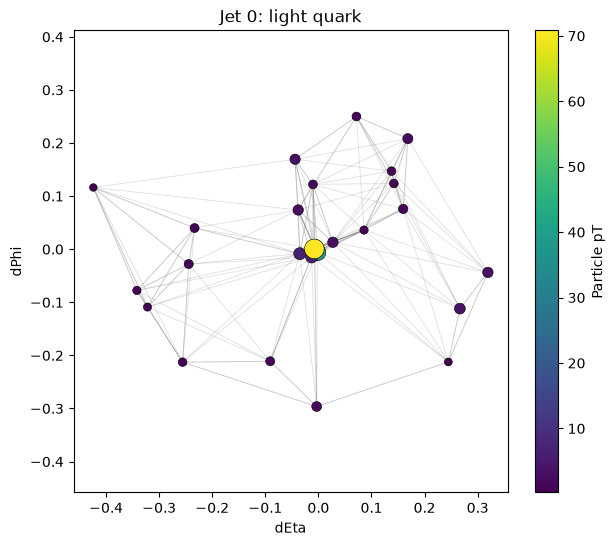

In [3]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

GRAPH_INDEX = 0
graph = jet_graphs[GRAPH_INDEX].cpu()
positions = graph.pos.numpy()
edges = graph.edge_index.numpy()
particle_pt = graph.x[:, 0].numpy()

# Draw graph edges as line segments between particle positions.
segments = np.stack(
    [positions[edges[0]], positions[edges[1]]],
    axis=1,
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.add_collection(
    LineCollection(segments, colors="gray", linewidths=0.6, alpha=0.25)
)

# Larger and brighter nodes represent particles with higher transverse momentum.
node_sizes = 20 + 180 * np.sqrt(particle_pt / particle_pt.max())
nodes = ax.scatter(
    positions[:, 0],
    positions[:, 1],
    s=node_sizes,
    c=particle_pt,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.4,
    zorder=2,
)

target_name = "gluon" if graph.y.item() == 1 else "light quark"
ax.set_title(f"Jet {GRAPH_INDEX}: {target_name}")
ax.set_xlabel("dEta")
ax.set_ylabel("dPhi")
ax.autoscale()
ax.set_aspect("equal", adjustable="datalim")
fig.colorbar(nodes, ax=ax, label="Particle pT")
plt.show()

# Check one graph

This cell prints one graph and its tensor shapes. It checks that the graph was created correctly.

In [4]:
g = jet_graphs[10]

print(g)
print(g.x.shape)
print(g.edge_index.shape)
print(g.y)
print(g.original_flavor)

Data(x=[34, 3], edge_index=[2, 272], y=[1], pos=[34, 2], original_flavor=[1], event_id=[1])
torch.Size([34, 3])
torch.Size([2, 272])
tensor([1])
tensor([21])


# Dataset split

The next cells split the graphs into training, validation, and test sets. Jets from the same event stay in the same set.

In [5]:
import random

def event_identity(graph):
    return (int(graph.run.item()), int(graph.lumi.item()), int(graph.event.item()))


# Get each composite event identity once so an event cannot cross subsets.
all_event_ids = sorted({event_identity(graph) for graph in jet_graphs})
random.Random(42).shuffle(all_event_ids)

# Split unique events into 70% training, 15% validation, and 15% test.
num_events = len(all_event_ids)
num_train = int(num_events * 0.70)
num_validation = int(num_events * 0.15)

train_events = set(all_event_ids[:num_train])
validation_events = set(
    all_event_ids[num_train:num_train + num_validation]
)
test_events = set(all_event_ids[num_train + num_validation:])

# Assign every jet according to its composite event identity.
train_graphs = [
    graph for graph in jet_graphs
    if event_identity(graph) in train_events
]
validation_graphs = [
    graph for graph in jet_graphs
    if event_identity(graph) in validation_events
]
test_graphs = [
    graph for graph in jet_graphs
    if event_identity(graph) in test_events
]

print(f"Total jets: {len(jet_graphs):,}")
print(f"Train jets: {len(train_graphs):,}")
print(f"Validation jets: {len(validation_graphs):,}")
print(f"Test jets: {len(test_graphs):,}")


Total jets: 13,912
Train jets: 9,736
Validation jets: 2,084
Test jets: 2,092


In [6]:
assert train_events.isdisjoint(validation_events)
assert train_events.isdisjoint(test_events)
assert validation_events.isdisjoint(test_events)
assert len(train_graphs) + len(validation_graphs) + len(test_graphs) == len(jet_graphs)

print("Event-safe split passed.")

Event-safe split passed.


# Data loaders

This cell groups jet graphs into batches. The training loader shuffles the graphs.

In [7]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    validation_graphs,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs,
    batch_size=32,
    shuffle=False
)

batch = next(iter(train_loader))

print(batch.x.shape)
print(batch.edge_index.shape)
print(batch.y.shape)
print(batch.batch.shape)

torch.Size([1037, 3])
torch.Size([2, 8296])
torch.Size([32])
torch.Size([1037])


# GNN model

This cell defines the neural network. It processes particles and produces one output for each jet.

In [8]:
import torch.nn as nn
from torch_geometric.nn import EdgeConv, global_mean_pool


class JetGNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        # EdgeConv combines x_i and (x_j - x_i), so its MLP input is doubled.
        self.conv1 = EdgeConv(
            nn=nn.Sequential(
                nn.Linear(2 * num_features, 64),
                nn.ReLU(),
                nn.Linear(64, 64),
            ),
            aggr="max",
        )

        self.conv2 = EdgeConv(
            nn=nn.Sequential(
                nn.Linear(2 * 64, 128),
                nn.ReLU(),
                nn.Linear(128, 128),
            ),
            aggr="max",
        )

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))

        # Combine all particle representations into one vector per jet.
        x = global_mean_pool(x, batch)

        x = torch.relu(self.fc1(x))
        return self.fc2(x).squeeze(-1)


model = JetGNN(num_features=len(particle_feature_names))
print(model)

JetGNN(
  (conv1): EdgeConv(nn=Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (conv2): EdgeConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


# Check the model output

This cell runs one batch through the model. It checks that there is one logit for each jet.

In [9]:
# Check that the model returns one logit for every jet in the batch.
model.eval()
with torch.no_grad():
    logits = model(batch.x, batch.edge_index, batch.batch)

print("Input particles:", batch.x.shape)
print("Batch targets:", batch.y.shape)
print("Output logits:", logits.shape)
assert logits.shape == batch.y.shape

Input particles: torch.Size([1037, 3])
Batch targets: torch.Size([32])
Output logits: torch.Size([32])


# Model training

This cell trains the model and checks validation performance after each epoch. It then evaluates the test set.

In [10]:
# Train the binary jet classifier.
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JetGNN(num_features=len(particle_feature_names)).to(device)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_jets = 0

    for batch in loader:
        batch = batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.float()
            loss = loss_function(logits, targets)

            if training:
                loss.backward()
                optimizer.step()

        predictions = (logits >= 0).long()
        total_loss += loss.item() * batch.num_graphs
        total_correct += (predictions == batch.y).sum().item()
        total_jets += batch.num_graphs

    return total_loss / total_jets, total_correct / total_jets


best_validation_loss = float("inf")
best_model_state = None
history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": [],
}

print(f"Training on: {device}")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    validation_loss, validation_accuracy = run_epoch(
        validation_loader, training=False
    )

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_accuracy"].append(validation_accuracy)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = {
            name: parameter.detach().cpu().clone()
            for name, parameter in model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f}, accuracy {train_accuracy:.3f} | "
        f"validation loss {validation_loss:.4f}, "
        f"accuracy {validation_accuracy:.3f}"
    )

# Restore the parameters from the epoch with the lowest validation loss.
model.load_state_dict(best_model_state)
test_loss, test_accuracy = run_epoch(test_loader, training=False)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.3f}")

Training on: cuda


d:\OneDrive - The University of Manchester\summer2026\SCIML\jet praticales\.venv\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 01 | train loss 0.5669, accuracy 0.698 | validation loss 0.5426, accuracy 0.738
Epoch 02 | train loss 0.5288, accuracy 0.740 | validation loss 0.5402, accuracy 0.738
Epoch 03 | train loss 0.5249, accuracy 0.744 | validation loss 0.5252, accuracy 0.748
Epoch 04 | train loss 0.5228, accuracy 0.748 | validation loss 0.5211, accuracy 0.756
Epoch 05 | train loss 0.5187, accuracy 0.747 | validation loss 0.5241, accuracy 0.751
Epoch 06 | train loss 0.5150, accuracy 0.751 | validation loss 0.5146, accuracy 0.754
Epoch 07 | train loss 0.5140, accuracy 0.751 | validation loss 0.5195, accuracy 0.739
Epoch 08 | train loss 0.5108, accuracy 0.754 | validation loss 0.5156, accuracy 0.758
Epoch 09 | train loss 0.5116, accuracy 0.752 | validation loss 0.5199, accuracy 0.753
Epoch 10 | train loss 0.5089, accuracy 0.756 | validation loss 0.5248, accuracy 0.753
Test loss: 0.5133 | Test accuracy: 0.756


# Training results

This cell plots training and validation loss and accuracy. It helps us see if the model is learning.

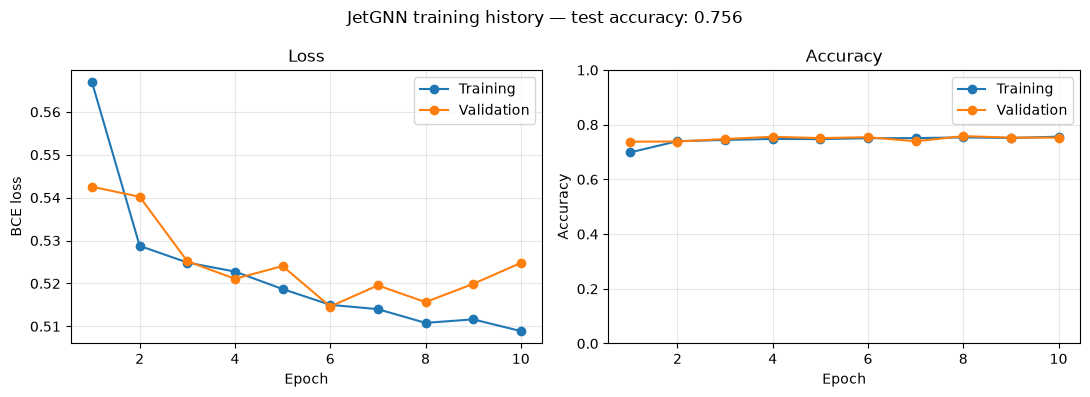

In [11]:
# Visualise the training and validation history.
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Training")
axes[0].plot(epochs, history["validation_loss"], marker="o", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Training")
axes[1].plot(epochs, history["validation_accuracy"], marker="o", label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle(f"JetGNN training history — test accuracy: {test_accuracy:.3f}")
fig.tight_layout()
plt.show()